# Extreme Modelling Plots

The extremes methodology is unfortunately only in `R` rather than `python`. To maintain similar plotting styles, we load up intermediate data processed from the `R` routines and plot using the `python` routines.

Jimmy Butler, November 2025

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
X_train = pd.read_csv('plotting_data/gbex_snow_X.csv')
variables = X_train.columns

In [3]:
variables

Index(['cumulative_landfalling_area', 'max_south_extent', 'max_IWV_ais',
       'max_ocean_SLP_gradient', 'max_landfalling_v850hPa',
       'avg_landfalling_minomega'],
      dtype='object')

In [4]:
abbv_dict = {variables[3]: 'SLP',
             variables[4]: 'Wind',
             variables[5]: 'Omega',
             variables[2]: 'IWV',
             variables[0]: 'CLA',
             variables[1]: 'South'}

units_dict = {'SLP': 'hPa/km',
              'Wind': 'm/s',
              'Omega': 'Pa/s',
              'IWV': 'kg/m$^{2}$',
              'CLA': 'km$^{2}$ day',
              'South': 'deg. lat.'}

In [5]:
X_full_snow = pd.read_csv('plotting_data/gbex_snow_fullX.csv')
X_full_temp = pd.read_csv('plotting_data/gbex_temp_fullX.csv')

## Snowfall Results

### Variable Importance

In [8]:
importances = pd.read_csv('plotting_data/snow_gbex_VI.csv', index_col='features')
importances = importances.sort_values(by='avg_perm_diff', ascending=False)
importances['avg_diffs_scaled'] = importances['avg_perm_diff']/(importances['avg_perm_diff'].max())
importances = importances.round(4)

/tmp/ipykernel_2882546/2784766073.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels);


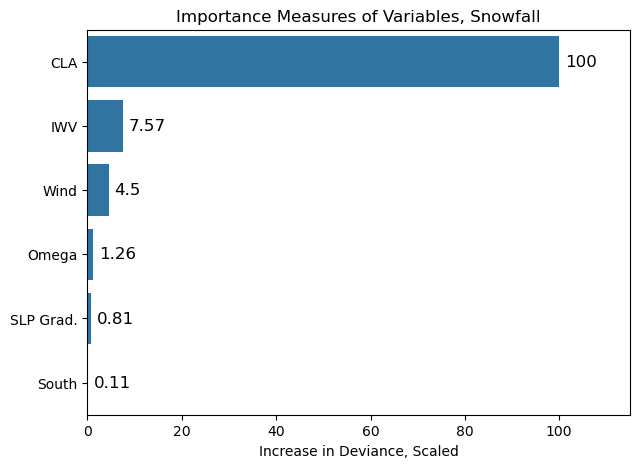

In [9]:
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=importances, y=importances.index, x=importances.avg_diffs_scaled*100, ax=ax)
ax.set_title('Importance Measures of Variables, Snowfall')
ax.set_xlabel('Increase in Deviance, Scaled')
ax.set_xlim([0,115])
ax.set_ylabel('')
ax.bar_label(ax.containers[0], padding=4, fontsize=12)
new_labels = ['CLA', 'IWV', 'Wind', 'Omega', 'SLP Grad.', 'South']
ax.set_yticklabels(new_labels);
fig.savefig('plots/importance_snow_gbex.png', dpi=300)

### 1D Partial Dependence Plots

In [7]:
plt_df_IWV = pd.read_csv('plotting_data/IWV_995_snow.csv')
plt_df_CLA = pd.read_csv('plotting_data/CLA_995_snow.csv')
plt_df_omega = pd.read_csv('plotting_data/omega_995_snow.csv')
plt_df_wind = pd.read_csv('plotting_data/wind_995_snow.csv')

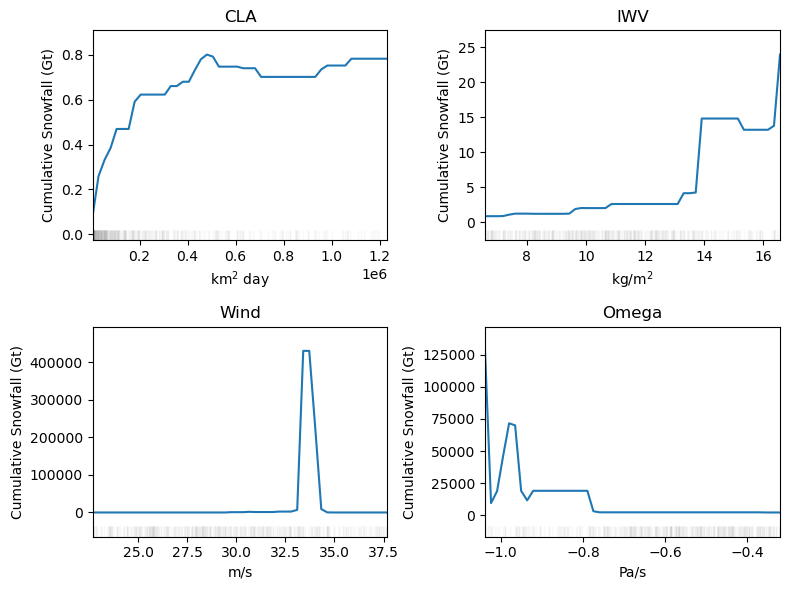

In [41]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(8, 6))
axs = axs.flatten()
axs[0].plot(plt_df_CLA['cumulative_landfalling_area'], plt_df_CLA['Q'])
sns.rugplot(x=X_full_snow['cumulative_landfalling_area'], ax=axs[0], height=0.05, color='gray', alpha=0.05)
extents = [plt_df_CLA['cumulative_landfalling_area'].min(), plt_df_CLA['cumulative_landfalling_area'].max()]
axs[0].set_xlim(extents)
axs[0].set_title('CLA')
axs[0].set_ylabel('Cumulative Snowfall (Gt)')
axs[0].set_xlabel('km$^{2}$ day')

axs[1].plot(plt_df_IWV['max_IWV_ais'], plt_df_IWV['Q'])
sns.rugplot(x=X_full_snow['max_IWV_ais'], ax=axs[1], height=0.05, color='gray', alpha=0.05)
extents = [plt_df_IWV['max_IWV_ais'].min(), plt_df_IWV['max_IWV_ais'].max()]
axs[1].set_xlim(extents)
axs[1].set_title('IWV')
axs[1].set_ylabel('Cumulative Snowfall (Gt)')
axs[1].set_xlabel('kg/m$^{2}$')


axs[2].plot(plt_df_wind['max_landfalling_v850hPa'], plt_df_wind['Q'])
sns.rugplot(x=X_full_snow['max_landfalling_v850hPa'], ax=axs[2], height=0.05, color='gray', alpha=0.05)
extents = [plt_df_wind['max_landfalling_v850hPa'].min(), plt_df_wind['max_landfalling_v850hPa'].max()]
axs[2].set_xlim(extents)
axs[2].set_title('Wind')
axs[2].set_ylabel('Cumulative Snowfall (Gt)')
axs[2].set_xlabel('m/s')

axs[3].plot(plt_df_omega['avg_landfalling_minomega'], plt_df_omega['Q'])
sns.rugplot(x=X_full_snow['avg_landfalling_minomega'], ax=axs[3], height=0.05, color='gray', alpha=0.05)
extents = [plt_df_omega['avg_landfalling_minomega'].min(), plt_df_omega['avg_landfalling_minomega'].max()]
axs[3].set_xlim(extents)
axs[3].set_title('Omega')
axs[3].set_ylabel('Cumulative Snowfall (Gt)')
axs[3].set_xlabel('Pa/s')

plt.tight_layout()
plt.savefig('snowfall_1d_pdp_extreme.png', dpi=300)

### 2D Partial Dependence Plots

In [10]:
plt_df_CLA = pd.read_csv('plotting_data/IWV_CLA_995_snow.csv')
plt_df_omega = pd.read_csv('plotting_data/IWV_omega_995_snow.csv')
plt_df_wind = pd.read_csv('plotting_data/IWV_wind_995_snow.csv')

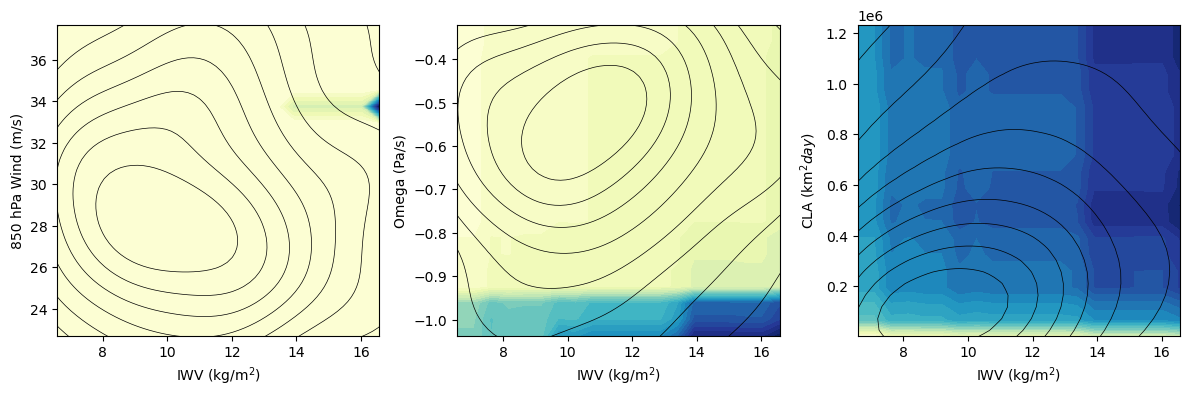

In [12]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))

grid1 = np.unique(plt_df_wind.max_IWV_ais)
grid2 = np.unique(plt_df_wind.max_landfalling_v850hPa)
axs[0].contourf(grid1, grid2,
                plt_df_wind.Q.to_numpy().reshape(20,20),
                cmap='YlGnBu', levels=25)
axs[0].set_ylim(min(grid2), max(grid2))
axs[0].set_xlim(min(grid1), max(grid1))
sns.kdeplot(x=X_full_snow['max_IWV_ais'], y=X_full_snow['max_landfalling_v850hPa'], ax=axs[0], levels=10, color="black", linewidths=0.5, fill=False)

grid1 = np.unique(plt_df_omega.max_IWV_ais)
grid2 = np.unique(plt_df_omega.avg_landfalling_minomega)
axs[1].contourf(grid1, grid2,
                np.log(plt_df_omega.Q.to_numpy().reshape(20,20)),
                cmap='YlGnBu', levels=25)
axs[1].set_ylim(min(grid2), max(grid2))
axs[1].set_xlim(min(grid1), max(grid1))
sns.kdeplot(x=X_full_snow['max_IWV_ais'], y=X_full_snow['avg_landfalling_minomega'], ax=axs[1], levels=10, color="black", linewidths=0.5, fill=False)

grid1 = np.unique(plt_df_CLA.max_IWV_ais)
grid2 = np.unique(plt_df_CLA.cumulative_landfalling_area)
axs[2].contourf(grid1, grid2,
                np.log(plt_df_CLA.Q.to_numpy().reshape(20,20)),
                cmap='YlGnBu', levels=25)
axs[2].set_ylim(min(grid2), max(grid2))
axs[2].set_xlim(min(grid1), max(grid1))
sns.kdeplot(x=X_full_snow['max_IWV_ais'], y=X_full_snow['cumulative_landfalling_area'], ax=axs[2], levels=10, color="black", linewidths=0.5, fill=False)

plt.tight_layout()

axs[0].set_ylabel('850 hPa Wind (m/s)')
axs[0].set_xlabel('IWV (kg/m$^{2}$)')
axs[1].set_ylabel('Omega (Pa/s)')
axs[1].set_xlabel('IWV (kg/m$^{2}$)')
axs[2].set_ylabel('CLA (km$^{2} day$)')
axs[2].set_xlabel('IWV (kg/m$^{2}$)');

plt.savefig('plots/snowfall_2d_pdp_gbex.png', dpi=300)

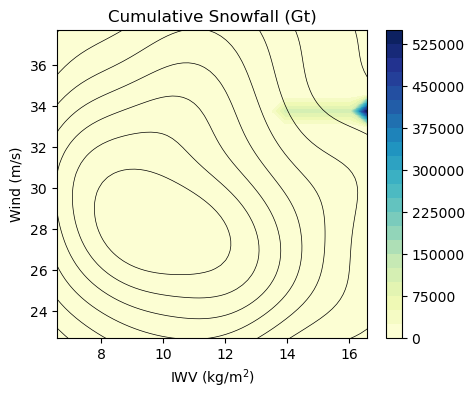

In [30]:
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(5, 4))

grid1 = np.unique(plt_df_wind.max_IWV_ais)
grid2 = np.unique(plt_df_wind.max_landfalling_v850hPa)
contour = axs.contourf(grid1, grid2,
                plt_df_wind.Q.to_numpy().reshape(20,20),
                cmap='YlGnBu', levels=25)

axs.set_ylim(min(grid2), max(grid2))
axs.set_xlim(min(grid1), max(grid1))
axs.set_xlabel('IWV (kg/m$^{2}$)')
axs.set_ylabel('Wind (m/s)')
axs.set_title('Cumulative Snowfall (Gt)')
sns.kdeplot(x=X_full_snow['max_IWV_ais'], y=X_full_snow['max_landfalling_v850hPa'], ax=axs, levels=10, color="black", linewidths=0.5, fill=False)
fig.colorbar(contour, ax=axs)
plt.savefig('plots/AGU_snowfall_2d_pdp_gbex.png', dpi=300);

## Temperature Results

### Variable Importance

In [47]:
importances = pd.read_csv('plotting_data/temp_gbex_VI.csv', index_col='features')
importances = importances.sort_values(by='avg_perm_diff', ascending=False)
importances['avg_diffs_scaled'] = importances['avg_perm_diff']/(importances['avg_perm_diff'].max())

In [49]:
importances

,avg_perm_diff,avg_diffs_scaled
features,,
max_ocean_SLP_gradient,0.004350,1.000000
cumulative_landfalling_area,0.001914,0.439937
max_south_extent,0.001234,0.283758
max_landfalling_v850hPa,0.001203,0.276472
max_IWV_ais,0.000000,0.000000
avg_landfalling_minomega,0.000000,0.000000


/tmp/ipykernel_1857766/4001212456.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels);


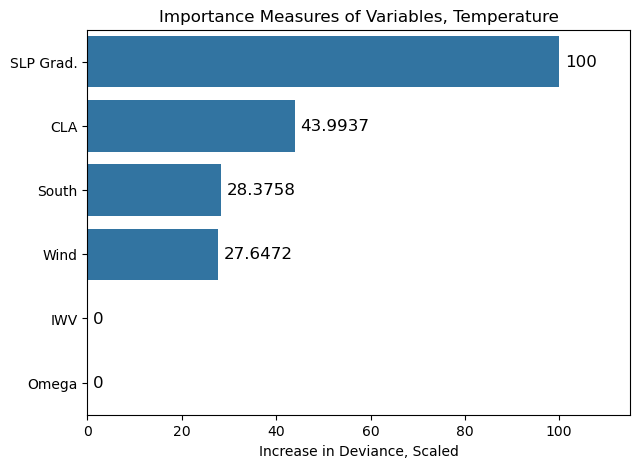

In [50]:
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=importances, y=importances.index, x=importances.avg_diffs_scaled*100, ax=ax)
ax.set_title('Importance Measures of Variables, Temperature')
ax.set_xlabel('Increase in Deviance, Scaled')
ax.set_xlim([0,115])
ax.set_ylabel('')
ax.bar_label(ax.containers[0], padding=4, fontsize=12)
new_labels = ['SLP Grad.', 'CLA', 'South', 'Wind', 'IWV', 'Omega']
ax.set_yticklabels(new_labels);
fig.savefig('plots/importance_temp_gbex.png', dpi=300)

### 1D Partial Dependence Plots

In [60]:
plt_df_SLP = pd.read_csv('plotting_data/SLP_995_temp.csv')
plt_df_south = pd.read_csv('plotting_data/south_995_temp.csv')
plt_df_wind = pd.read_csv('plotting_data/wind_995_temp.csv')
plt_df_IWV = pd.read_csv('plotting_data/IWV_995_temp.csv')

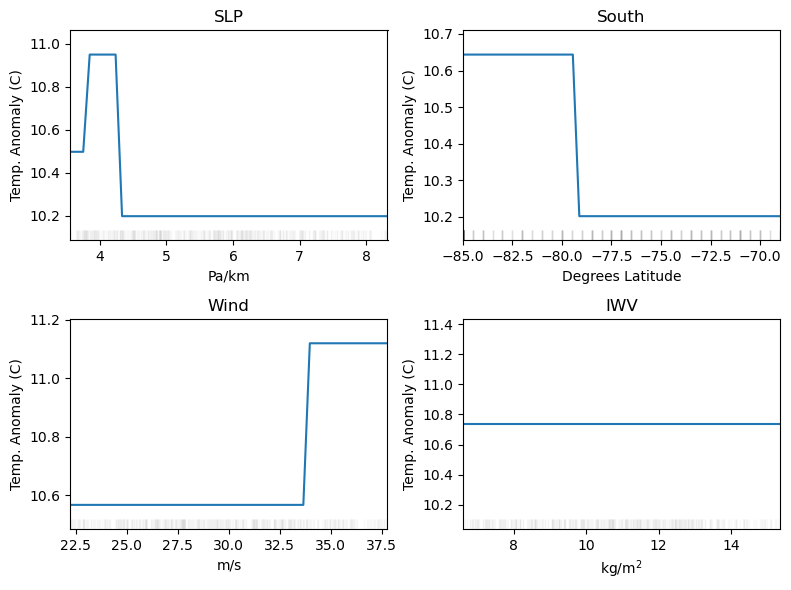

In [61]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(8, 6))
axs = axs.flatten()
axs[0].plot(plt_df_SLP['max_ocean_SLP_gradient'], plt_df_SLP['Q'])
sns.rugplot(x=X_full_temp['max_ocean_SLP_gradient'], ax=axs[0], height=0.05, color='gray', alpha=0.05)
extents = [plt_df_SLP['max_ocean_SLP_gradient'].min(), plt_df_SLP['max_ocean_SLP_gradient'].max()]
axs[0].set_xlim(extents)
axs[0].set_title('SLP')
axs[0].set_ylabel('Temp. Anomaly (C)')
axs[0].set_xlabel('Pa/km')

axs[1].plot(plt_df_south['max_south_extent'], plt_df_south['Q'])
sns.rugplot(x=X_full_temp['max_south_extent'], ax=axs[1], height=0.05, color='gray', alpha=0.05)
extents = [plt_df_south['max_south_extent'].min(), plt_df_south['max_south_extent'].max()]
axs[1].set_xlim(extents)
axs[1].set_title('South')
axs[1].set_ylabel('Temp. Anomaly (C)')
axs[1].set_xlabel('Degrees Latitude')


axs[2].plot(plt_df_wind['max_landfalling_v850hPa'], plt_df_wind['Q'])
sns.rugplot(x=X_full_temp['max_landfalling_v850hPa'], ax=axs[2], height=0.05, color='gray', alpha=0.05)
extents = [plt_df_wind['max_landfalling_v850hPa'].min(), plt_df_wind['max_landfalling_v850hPa'].max()]
axs[2].set_xlim(extents)
axs[2].set_title('Wind')
axs[2].set_ylabel('Temp. Anomaly (C)')
axs[2].set_xlabel('m/s')

axs[3].plot(plt_df_IWV['max_IWV_ais'], plt_df_IWV['Q'])
sns.rugplot(x=X_full_temp['max_IWV_ais'], ax=axs[3], height=0.05, color='gray', alpha=0.05)
extents = [plt_df_IWV['max_IWV_ais'].min(), plt_df_IWV['max_IWV_ais'].max()]
axs[3].set_xlim(extents)
axs[3].set_title('IWV')
axs[3].set_ylabel('Temp. Anomaly (C)')
axs[3].set_xlabel('kg/m$^{2}$')

plt.tight_layout()
plt.savefig('temp_1d_pdp_extreme.png', dpi=300)

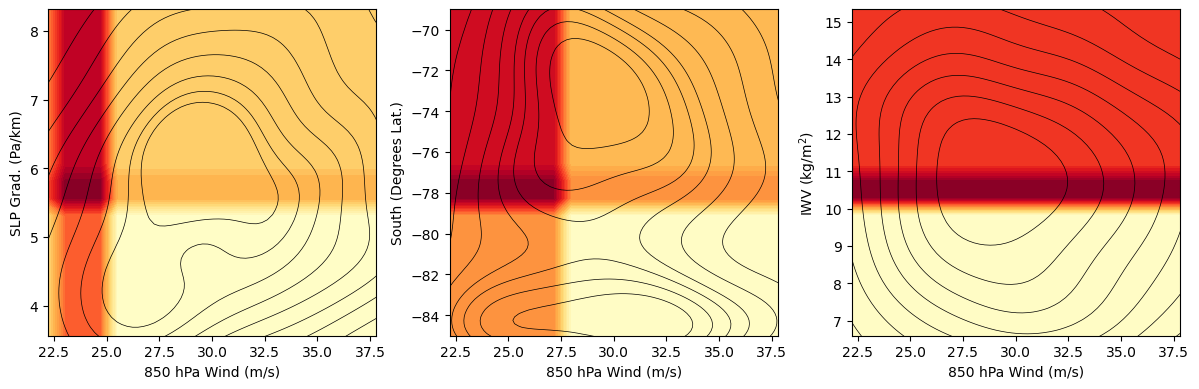

In [64]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))

plt_df_south = pd.read_csv('plotting_data/south_wind_995_temp.csv')
plt_df_SLP = pd.read_csv('plotting_data/SLP_wind_995_temp.csv')
plt_df_IWV = pd.read_csv('plotting_data/IWV_wind_995_temp.csv')

grid1 = np.unique(plt_df_SLP.max_landfalling_v850hPa)
grid2 = np.unique(plt_df_SLP.max_ocean_SLP_gradient)
axs[0].contourf(grid1, grid2,
                plt_df_SLP.Q.to_numpy().reshape(20,20),
                cmap='YlOrRd', levels=25)
axs[0].set_ylim(min(grid2), max(grid2))
axs[0].set_xlim(min(grid1), max(grid1))
sns.kdeplot(x=X_full_temp['max_landfalling_v850hPa'], y=X_full_temp['max_ocean_SLP_gradient'], ax=axs[0], levels=10, color="black", linewidths=0.5, fill=False)

grid1 = np.unique(plt_df_south.max_landfalling_v850hPa)
grid2 = np.unique(plt_df_south.max_south_extent)
axs[1].contourf(grid1, grid2,
                plt_df_south.Q.to_numpy().reshape(20,20),
                cmap='YlOrRd', levels=25)
axs[1].set_ylim(min(grid2), max(grid2))
axs[1].set_xlim(min(grid1), max(grid1))
sns.kdeplot(x=X_full_temp['max_landfalling_v850hPa'], y=X_full_temp['max_south_extent'], ax=axs[1], levels=10, color="black", linewidths=0.5, fill=False)

grid1 = np.unique(plt_df_IWV.max_landfalling_v850hPa)
grid2 = np.unique(plt_df_IWV.max_IWV_ais)
axs[2].contourf(grid1, grid2,
                plt_df_IWV.Q.to_numpy().reshape(20,20),
                cmap='YlOrRd', levels=25)
axs[2].set_ylim(min(grid2), max(grid2))
axs[2].set_xlim(min(grid1), max(grid1))
sns.kdeplot(x=X_full_temp['max_landfalling_v850hPa'], y=X_full_temp['max_IWV_ais'], ax=axs[2], levels=10, color="black", linewidths=0.5, fill=False)

plt.tight_layout()

axs[0].set_xlabel('850 hPa Wind (m/s)')
axs[0].set_ylabel('SLP Grad. (Pa/km)')
axs[1].set_ylabel('South (Degrees Lat.)')
axs[1].set_xlabel('850 hPa Wind (m/s)')
axs[2].set_xlabel('850 hPa Wind (m/s)')
axs[2].set_ylabel('IWV (kg/m$^{2}$)');

plt.savefig('plots/temp_2d_pdp_gbex.png', dpi=300)
